# Lab Instructions

You are working as an analyst for a consulting agency that has been hired to study and improve productivity at a mid-sized company.  Morale is very low and, after speaking with employees, several common complaints kept coming up:

* New employees complained that more tenured employees were lazy and unproductive.
* More tenured employees complained that the newer employees didn't focus and were therefore unproductive.
* Managers were worried that remote workers might be less productive.
* In-person employees found it impossible to focus and be productive when their desk was in the open plan area.
* Many people said they had so much administrative work to do they could only be truly productive if they worked overtime.
* Everyone complained that there were too many meetings.

The consulting agency carefully collected data on a number of factors including number of years at the company, focus (higher is better), productivity (higher is better), department, meetings per week, and desk location can be found in Employee_productivity.csv.

1. Determine which feature - years at the company, hours worked, or focus - has the strongest linear relationship with productivity.  Show a visualization and calculate R-squared for all three relationships to justify your answer.

2. Build on that linear regression model to determine what other featuers also impact productivity. Using both visualzations and R-squared values, build a model that can predicts employee productivity at this company. Evaluate each feature in the dataset.

3. Write a short (a few sentences) summary of how the different factors in the data relate to employee productivity.  What recommendations would you make so that employees can be as productive as possible?

**For the purposes of this lab you MUST use the model building techniques we covered in class.  Failure to do so will automatically result in a 20 point deduction.  I really want you to think about what you are doing and not just paste what you get from ChatGPT (which will often NOT do the correct thing by default).**



In [1]:
import pandas as pd

df = pd.read_csv('Employee_productivity.csv')

df.head()

,HoursWorked,FocusScore,ProductivityScore,Department,YearsAtCompany,TeamMeetingsPerWeek,DeskLocation
0,42.4,6.3,3127.96,Engineering,17,0,Open Plan
1,34.0,7.2,4742.60,HR,8,6,Private Office
2,47.2,5.6,2044.73,Sales,15,3,Remote
3,38.4,9.0,5818.92,HR,5,6,Private Office
4,36.4,2.5,1841.31,Sales,9,6,Remote


In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score

sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (8, 5)

df = pd.read_csv('Employee_productivity.csv')
df.head()

,HoursWorked,FocusScore,ProductivityScore,Department,YearsAtCompany,TeamMeetingsPerWeek,DeskLocation
0,42.4,6.3,3127.96,Engineering,17,0,Open Plan
1,34.0,7.2,4742.60,HR,8,6,Private Office
2,47.2,5.6,2044.73,Sales,15,3,Remote
3,38.4,9.0,5818.92,HR,5,6,Private Office
4,36.4,2.5,1841.31,Sales,9,6,Remote


In [2]:
features = ['YearsAtCompany', 'HoursWorked', 'FocusScore']
target = 'ProductivityScore'

for feature in features:
    X = df[[feature]]
    y = df[target]
    
    model = LinearRegression()
    model.fit(X, y)
    y_pred = model.predict(X)
    r2 = r2_score(y, y_pred)
    
    print(f"{feature} → R² = {r2:.4f}")

YearsAtCompany → R² = 0.0004
HoursWorked → R² = 0.0026
FocusScore → R² = 0.6777


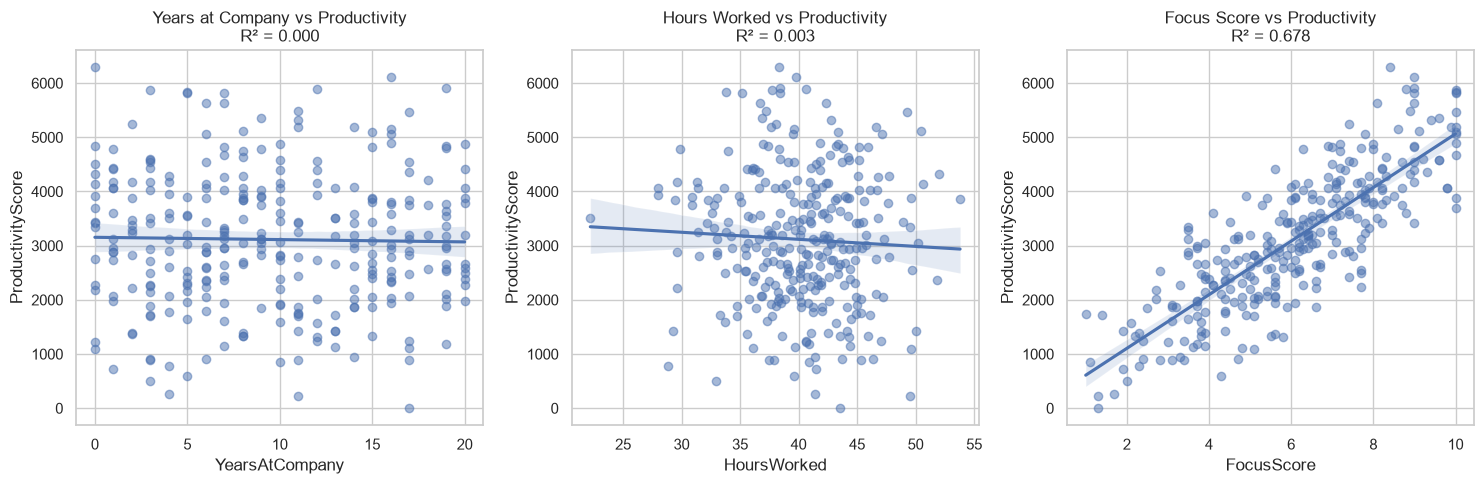

In [3]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

features = ['YearsAtCompany', 'HoursWorked', 'FocusScore']
titles = ['Years at Company', 'Hours Worked', 'Focus Score']

for i, feature in enumerate(features):
    sns.regplot(data=df, x=feature, y='ProductivityScore', ax=axes[i], scatter_kws={'alpha':0.5})
    axes[i].set_title(f'{titles[i]} vs Productivity\nR² = {r2_score(df["ProductivityScore"], LinearRegression().fit(df[[feature]], df["ProductivityScore"]).predict(df[[feature]])):.3f}')

plt.tight_layout()
plt.show()

TeamMeetingsPerWeek → R² = 0.0542


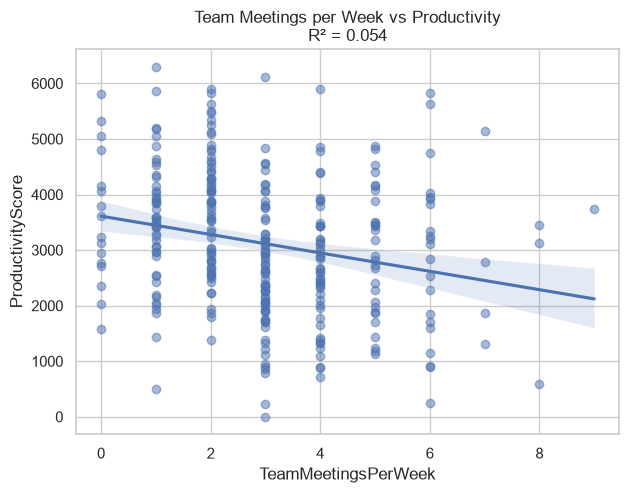

In [4]:
# Team Meetings
X = df[['TeamMeetingsPerWeek']]
y = df['ProductivityScore']
model = LinearRegression()
model.fit(X, y)
r2 = r2_score(y, model.predict(X))
print(f"TeamMeetingsPerWeek → R² = {r2:.4f}")

plt.figure(figsize=(7, 5))
sns.regplot(data=df, x='TeamMeetingsPerWeek', y='ProductivityScore', scatter_kws={'alpha':0.5})
plt.title(f'Team Meetings per Week vs Productivity\nR² = {r2:.3f}')
plt.show()

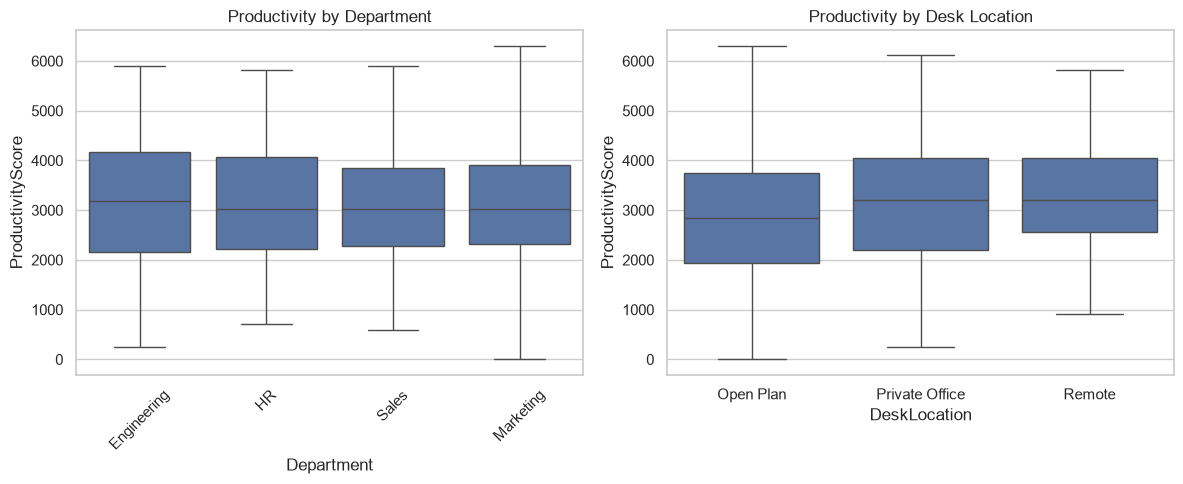

In [5]:
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
sns.boxplot(data=df, x='Department', y='ProductivityScore')
plt.title('Productivity by Department')
plt.xticks(rotation=45)

plt.subplot(1, 2, 2)
sns.boxplot(data=df, x='DeskLocation', y='ProductivityScore')
plt.title('Productivity by Desk Location')

plt.tight_layout()
plt.show()

In [6]:
# Create dummy variables for DeskLocation
df_model = pd.get_dummies(df, columns=['DeskLocation'], drop_first=True)

# Features to include
X = df_model[['FocusScore', 'TeamMeetingsPerWeek', 'DeskLocation_Private Office', 'DeskLocation_Remote']]
y = df_model['ProductivityScore']

model = LinearRegression()
model.fit(X, y)
y_pred = model.predict(X)
r2 = r2_score(y, y_pred)

print(f"Multiple Regression R² = {r2:.4f}")
print("\nCoefficients:")
for feature, coef in zip(X.columns, model.coef_):
    print(f"  {feature}: {coef:.2f}")
print(f"Intercept: {model.intercept_:.2f}")

Multiple Regression R² = 0.6832

Coefficients:
  FocusScore: 512.07
  TeamMeetingsPerWeek: 26.89
  DeskLocation_Private Office: -99.49
  DeskLocation_Remote: -222.89
Intercept: 32.10


In [ ]:
FocusScore has by far the strongest linear relationship with productivity (R^2 = 0.68).
Years at the company and hours worked show almost no relationship with productivity.
Team meetings have a weak negative relationship (more meetings = slightly lower productivity).
Desk location shows a small difference: Private Office and Remote workers tend to have slightly higher productivity than open plan workers. Department does not appear to matter much.

Recommendations:

Prioritize focus — The biggest lever for improving productivity is helping employees maintain high focus. This could include reducing interruptions, protecting deep-work time, and improving the work environment.

Reduce unnecessary meetings — There is a slight negative relationship between number of meetings and productivity. The company should audit meetings and cut low-value ones.

Desk location — Open Plan desks are associated with slightly lower productivity. Where possible, offer private offices or quiet remote options, especially for roles that require deep concentration.

Do not focus on tenure or raw hours — Neither years at the company nor hours worked meaningfully predict productivity. Emphasizing long hours or seniority is unlikely to improve results.